In [11]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

# Directory containing the .dat files
directory_path = '/home/yts/dassflow2d/code/bin_A/res/'

# Get all .dat files in the directory
file_paths = glob.glob(directory_path + '*.dat')

# Initialize lists to store x and h values for each file
all_x_values = []
all_h_values = []
areas = []  # To store the area under each curve
max_x_values = []  # To store the maximum x value where h > threshold
times = []  # To store the time extracted from filenames

# Define a threshold to filter out noise in h values
threshold = 0.0012

# Regex pattern to extract the time from filenames
time_pattern = re.compile(r'result_([\d.E+-]+)\.dat')

# Track if time zero is found
time_zero_found = False

# Loop over each file
for file_path in file_paths:
    x_values, h_values = [], []
    
    # Extract time from the filename
    match = time_pattern.search(file_path)
    if match:
        time_str = match.group(1)
        try:
            time = float(time_str)
            times.append(time)
            if time == 0:
                time_zero_found = True
        except ValueError:
            times.append(np.nan)
            continue
    else:
        # Handle the special case for time zero
        if '/home/yts/dassflow2d/code/bin_A/res/result_initial.dat' in file_path:
            time = 0
            times.append(time)
            time_zero_found = True
        else:
            times.append(np.nan)
            continue

    # Open the .dat file and process it line by line
    with open(file_path, 'r') as file:
        for line in file:
            # Skip lines that start with '#'
            if line.startswith('#'):
                continue
            
            # Strip any leading/trailing whitespace and split the line into columns
            columns = line.strip().split()
            
            # Ensure there are enough columns to process (i.e., it's not a blank line)
            if len(columns) >= 8:
                try:
                    # Convert the relevant columns to floats
                    y_value = float(columns[2])  # y is the 3rd column (index 2)
                    h_value = float(columns[4])  # h is the 5th column (index 4)
                    x_value = float(columns[1])
                    
                    # Check if y equals 4.750000000E-001
                    if y_value == 1.65000000E-001:
                        h_values.append(h_value)
                        x_values.append(x_value)
                except ValueError:
                    # Handle any conversion errors gracefully
                    continue

    # Store the x and h values for this file
    all_x_values.append(x_values)
    all_h_values.append(h_values)

    # Calculate the area under the curve using trapezoidal integration
    area = np.trapz(h_values, x_values)
    areas.append(area)

    # Find the maximum x value where h is greater than the threshold
    if x_values and h_values:
        max_x = max(x_value for x_value, h_value in zip(x_values, h_values) if h_value > threshold)
    else:
        max_x = np.nan
    max_x_values.append(max_x)

# If time zero was not found in the files, add it with NaN for max_x_value
if not time_zero_found:
    times.append(0)
    max_x_values.append(np.nan)

# Create a NumPy array to store time and max_x_value
data = np.column_stack((times, max_x_values))

# Sort the arrays based on time
sorted_indices = np.argsort(times)
times = np.array(times)[sorted_indices]
all_x_values = [all_x_values[i] for i in sorted_indices]
all_h_values = [all_h_values[i] for i in sorted_indices]
areas = [areas[i] for i in sorted_indices]
max_x_values = [max_x_values[i] for i in sorted_indices]

# Plotting
plt.figure()
plt.xlim(1.5,2)
plt.ylim(0,0.005)

# Plot each set of x and h values from the different files
for i, file_path in enumerate(file_paths):
    file_name = file_path.split('/')[-1]  # Extract the file name
    #plt.plot(all_x_values[i], all_h_values[i], label=f'{file_name} (Area = {areas[i]:.2f}, Max x = {max_x_values[i]:.2f})')

# Add legend to differentiate the plots
#plt.legend()

# Display the plot
plt.show()

nsom_3deg = np.loadtxt('nsom_data_3degrees.txt')

rho, mu, g = 1406, 12, 9.81
L, theta, H = 0.24, np.deg2rad(3), 0.03

plt.figure()
plt.grid()
plt.xlabel('$t$ (s)')
plt.ylabel('$x_{f}$ (m)')
plt.xlim(0.001, 1000)
plt.ylim(0.01, 10)
plt.xscale('log')
plt.yscale('log')
plt.scatter(((rho*g*np.cos(theta)*H**3)*data[:,0])/(12*mu*L**2), (data[:,1]- L)/L  ,color='blue')
plt.scatter(nsom_3deg[:,0], nsom_3deg[:,1],color='red')
#plt.scatter(muchiri_15deg[:,0], muchiri_15deg[:,1],color='red')
#plt.scatter(muchiri_onelayer_15deg[:,0], muchiri_onelayer_15deg[:,1],color='green')

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 401 and the array at index 1 has size 400

In [144]:
#np.savetxt('/home/yts/dassflow2d/cases/dambreak_tests/data_3deg_nsom.txt', data_3deg_nsom)

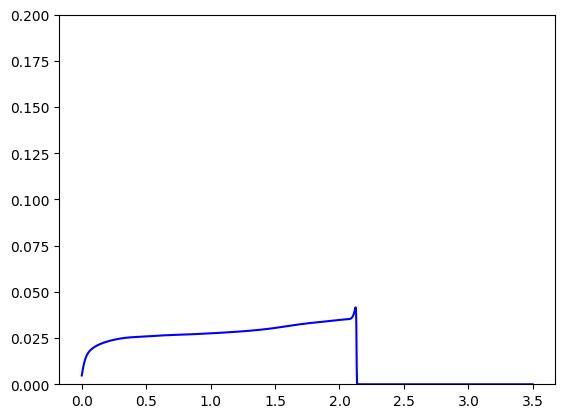

Data saved to muchiri2024_paper_15deg_dassflow_coeff_hydraulics_hspace_10s.txt


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize an empty list to store the h values
h_values, x_values, u_values, bathy_values = [], [], [], []

x_monitor = 2.00192300E+000
y_monitor = 1.45000000E-001

# Open the .dat file and process it line by line
with open('/home/yts/dassflow2d/code/bin_A/res/result_1.000037E+00.dat', 'r') as file:
    for line in file:
        # Skip lines that start with '#'
        if line.startswith('#'):
            continue
        
        # Strip any leading/trailing whitespace and split the line into columns
        columns = line.strip().split()
        
        # Ensure there are enough columns to process (i.e., it's not a blank line)
        if len(columns) >= 8:
            try:
                # Convert the relevant columns to floats
                y_value = float(columns[2])  # y is the 3rd column (index 2)
                h_value = float(columns[4])  # h is the 5th column (index 4)
                u_value = float(columns[7])  # v is the 8th column (index 7)
                bathy_value = float(columns[3])
                x_value = float(columns[1])
                # Check if y equals 0.15
                if y_value == y_monitor:
                    h_values.append(h_value)
                    x_values.append(x_value)
                    u_values.append(u_value)
                    bathy_values.append(bathy_value)
            except ValueError:
                # Handle any conversion errors gracefully
                continue

# Now h_values contains all h values where y is 0.15
#print(h_values)

plt.figure()
plt.ylim(0,0.2)
#plt.xlim(0,2.5)
#plt.scatter(0,0.12,color='black',s=30)
plt.plot(x_values, np.asarray(h_values) ,color='blue')
#plt.plot(x_values, bathy_values, color='black')
#plt.hlines(0.00983, 0, 3)
plt.show()

# Combine timesteps and h_values into a single 2D array
data = np.column_stack((x_values, np.asarray(h_values)))

# Save to a text file
output_path = "muchiri2024_paper_15deg_dassflow_coeff_hydraulics_hspace_10s.txt"
#np.savetxt(output_path, data, header="Position    H-value", fmt="%.6e", delimiter="\t")

print(f"Data saved to {output_path}")


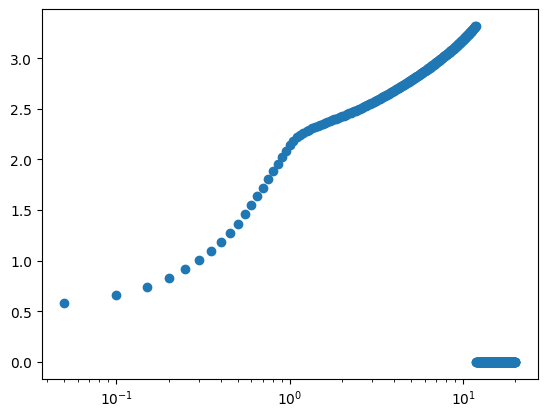

In [13]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

# Arrays to store results
times = []
x_values = []
h_values = []

# Directory containing the .dat files
directory_path = '/home/yts/dassflow2d/code/bin_A/res/'

# Get all .dat files in the directory
files = glob.glob(directory_path + '*.dat')

for file in files:
    # Extract time from filename using regex
    match = re.search(r'result_(\d\.\d+E[+-]?\d+)\.dat', file)
    if match:
        time = float(match.group(1))
        times.append(time)
    else:
        continue
    
    # Read file and process data
    with open(file, 'r') as f:
        lines = f.readlines()
    
    # Skip header lines and process data
    for line in lines[2:]:  # Assuming 2 header lines
        cols = line.split()
        x = float(cols[1])
        h = float(cols[4])
        
        if h < 0.00000007:
            x_values.append(x)
            break  # Stop after finding the first suitable value for this file

# Convert lists to NumPy arrays
times = np.array(times)
x_values = np.array(x_values)

plt.figure()
plt.xscale('log')
plt.scatter(times, x_values)

In [14]:
# Combine timesteps and h_values into a single 2D array
data = np.column_stack((times, np.asarray(x_values)))

# Save to a text file
output_path = "dambreak_dassflow_25deg_coeff_new.txt"
np.savetxt(output_path, data, header="Position    H-value", fmt="%.6e", delimiter="\t")

print(f"Data saved to {output_path}")

Data saved to dambreak_dassflow_25deg_coeff_new.txt


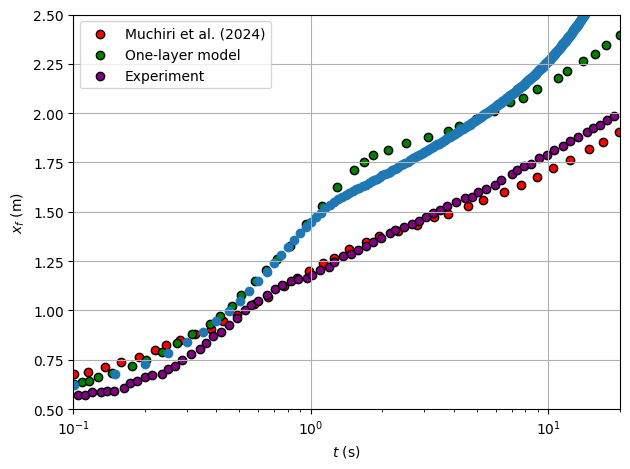

In [11]:
#nsom_10deg = np.loadtxt('nsom_data_10degrees.txt')
#data = np.loadtxt('/home/yts/dassflow2d/cases/dambreak_tests/data_25deg_muchiri_num.txt')
muchiri_15deg = np.loadtxt('dambreak_ancey/muchiri_2024_paper_15deg_dassflow_regimeA.txt')
muchiri_onelayer_15deg = np.loadtxt('dambreak_ancey/muchiri_2024_paper_15deg_onelayer.txt')
experiment = np.loadtxt('dambreak_ancey/muchiri_2024_paper_15deg_exp.txt')

plt.figure()
plt.grid()
plt.xlabel('$t$ (s)')
plt.ylabel('$x_{f}$ (m)')
plt.xlim(0.1, 20)
plt.ylim(0.5, 2.5)
plt.xscale('log')
#plt.scatter(data[:,0], data[:,1], color='blue', edgecolors='black' ,label='Dassflow')
plt.scatter(muchiri_15deg[:,0], muchiri_15deg[:,1],color='red', edgecolors='black', label='Muchiri et al. (2024)')
plt.scatter(muchiri_onelayer_15deg[:,0], muchiri_onelayer_15deg[:,1], edgecolors='black',color='green', label='One-layer model')
plt.scatter(experiment[:,0], experiment[:,1],color='purple', edgecolors='black', label='Experiment')
plt.scatter(times, x_values)
plt.legend()
plt.tight_layout()
#plt.savefig('/home/yts/dassflow2d/cases/dambreak_tests/DB_HB_muchiri_25deg.png', dpi=300)
#plt.yscale('log')
#L, H, theta = 0.317, 0.06, np.deg2rad(10)
#plt.scatter((data[:,0]*rho*g*np.cos(theta)*H**3)/(12*mu*L**2), (data[:,1]-L)/L)
#plt.scatter(nsom_10deg[:,0], nsom_10deg[:,1])

In [158]:
#np.savetxt('/home/yts/dassflow2d/cases/dambreak_tests/data_25deg_muchiri_num.txt', data)

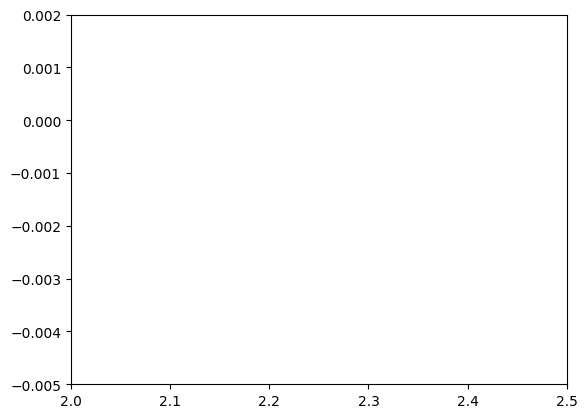

In [151]:
# Plotting
plt.figure()
plt.xlim(2,2.5)
plt.ylim(-0.005, 0.002)

for i, file_path in enumerate(file_paths):
    file_name = file_path.split('/')[-1]  # Extract the file name
    plt.plot(all_x_values[-3], all_h_values[-3])

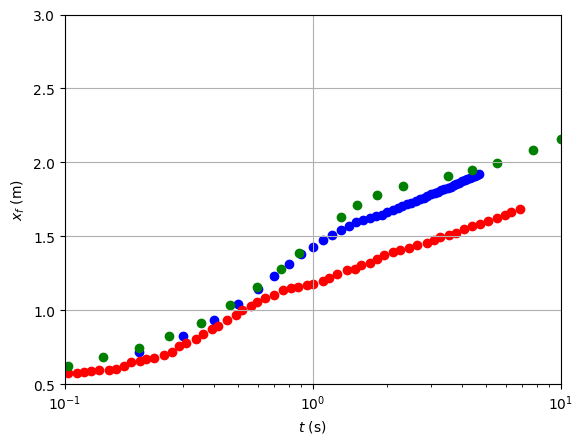

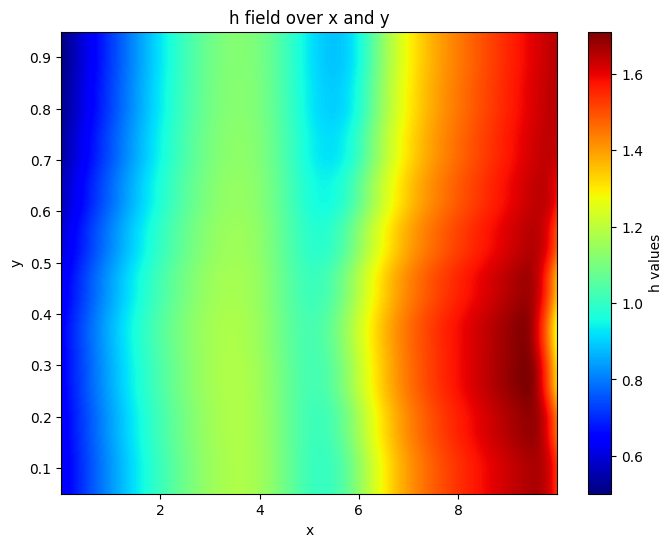

In [46]:
## import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists to store x, y, and h values
x_values = []
y_values = []
h_values = []

# Path to the .dat file
file_path = '/home/yts/dassflow2d/code/bin_A/res/result_1.000003E+01.dat'

# Read the data file
with open(file_path, 'r') as file:
    for line in file:
        # Skip lines that start with '#' (comments)
        if line.startswith('#'):
            continue
        
        # Strip any leading/trailing whitespace and split the line into columns
        columns = line.strip().split()
        
        # Ensure there are enough columns to process (i.e., it's not a blank line)
        if len(columns) >= 8:
            try:
                x_value = float(columns[1])
                y_value = float(columns[2])
                h_value = float(columns[4])
                
                x_values.append(x_value)
                y_values.append(y_value)
                h_values.append(h_value)
            except ValueError:
                continue

# Convert lists to numpy arrays for easier manipulation
x_values = np.array(x_values)
y_values = np.array(y_values)
h_values = np.array(h_values)

# Determine the unique x and y values to define the grid
unique_x = np.unique(x_values)
unique_y = np.unique(y_values)

# Create a grid to map the h values
h_grid = np.zeros((unique_y.size, unique_x.size))

# Fill the grid with h values
for i, (x, y, h) in enumerate(zip(x_values, y_values, h_values)):
    # Get the index in the grid for this x and y
    x_index = np.where(unique_x == x)[0][0]
    y_index = np.where(unique_y == y)[0][0]
    h_grid[y_index, x_index] = h

# Plotting the h field using imshow
plt.figure(figsize=(8, 6))
plt.imshow(h_grid, extent=(unique_x.min(), unique_x.max(), unique_y.min(), unique_y.max()), origin='lower', cmap='jet',
          aspect='auto')
plt.colorbar(label='h values')
plt.xlabel('x')
plt.ylabel('y')
plt.title('h field over x and y')
plt.show()


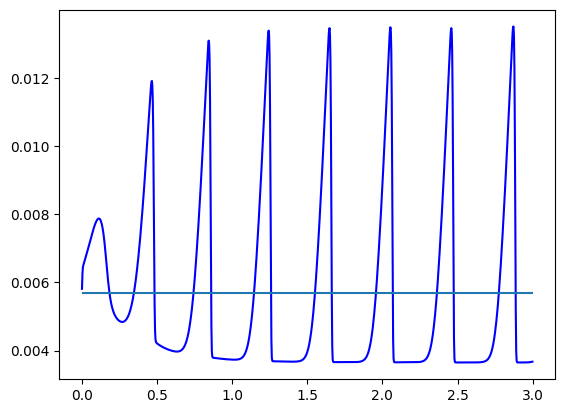

0.00581050567

In [93]:
##for roll waves ##
import matplotlib.pyplot as plt
import numpy as np

# Initialize an empty list to store the h values
h_values, x_values, bathy_values = [], [], []



# Open the .dat file and process it line by line
with open('/home/yts/dassflow2d/code/bin_A/res/result_9.000537E+00.dat', 'r') as file:
    for line in file:
        # Skip lines that start with '#'
        if line.startswith('#'):
            continue
        
        # Strip any leading/trailing whitespace and split the line into columns
        columns = line.strip().split()
        
        # Ensure there are enough columns to process (i.e., it's not a blank line)
        if len(columns) >= 8:
            try:
                # Convert the relevant columns to floats
                y_value = float(columns[2])  # y is the 3rd column (index 2)
                h_value = float(columns[4])  # h is the 5th column (index 4)
                bathy_value = float(columns[3])
                x_value = float(columns[1])
                # Check if y equals 0.15
                if y_value == 1.65000000E-001:
                    h_values.append(h_value)
                    x_values.append(x_value)
                    bathy_values.append(bathy_value)
            except ValueError:
                # Handle any conversion errors gracefully
                continue

# Now h_values contains all h values where y is 0.15
#print(h_values)

plt.figure()
#plt.xlim(1.4, 1.5)
#plt.scatter(0,0.12,color='black',s=30)
plt.plot(x_values, h_values ,color='blue')
#plt.plot(x_values, bathy_values, color='black')
plt.hlines(0.0057, 0, 3)
plt.show()
h_values[0]


In [201]:
#np.savetxt('/home/yts/dassflow2d/cases/roll_waves_tests/herschel_bulkley/HB_nx1001.txt', mesh1001_HB)

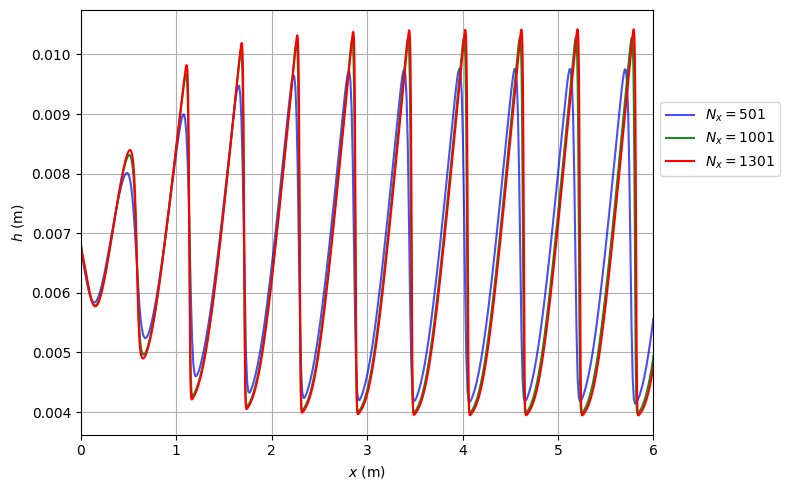

In [203]:
plt.figure(figsize=(8,5))
plt.grid()
plt.xlabel('$x$ (m)')
plt.ylabel('$h$ (m)')
plt.xlim(0,6)
#plt.ylim(0.012, 0.0135)
#plt.plot(np.linspace(0,10,np.asarray(mesh101_RW).shape[0]), mesh101_RW, color='green', label='$N_{x} = 101$')
#plt.plot(np.linspace(0,10,np.asarray(mesh301_RW).shape[0]), mesh301_RW, color='blue', label='$N_{x} = 301$')
#plt.plot(np.linspace(0,10,np.asarray(mesh501_RW).shape[0]), mesh501_RW, color='red', label='$N_{x} = 501$',alpha=0.3)
#plt.plot(np.linspace(0,10,np.asarray(mesh701_RW).shape[0]), mesh701_RW, color='darkviolet', label='$N_{x} = 701$',alpha=0.5)
plt.plot(np.linspace(0,6,np.asarray(mesh501_HB).shape[0]), mesh501_HB, color='blue', label='$N_{x} = 501$',alpha=0.7)
plt.plot(np.linspace(0,6,np.asarray(mesh1001_HB).shape[0]), mesh1001_HB, color='green', label='$N_{x} = 1001$',alpha=0.9)
plt.plot(np.linspace(0,6,np.asarray(mesh1301_HB).shape[0]), mesh1301_HB, color='red', label='$N_{x} = 1301$')

plt.legend(bbox_to_anchor=(1,0.8))
plt.tight_layout()
plt.savefig('/home/yts/dassflow2d/cases/roll_waves_tests/herschel_bulkley/herschel_bulkley_grid_sensitivity.png', dpi=300)

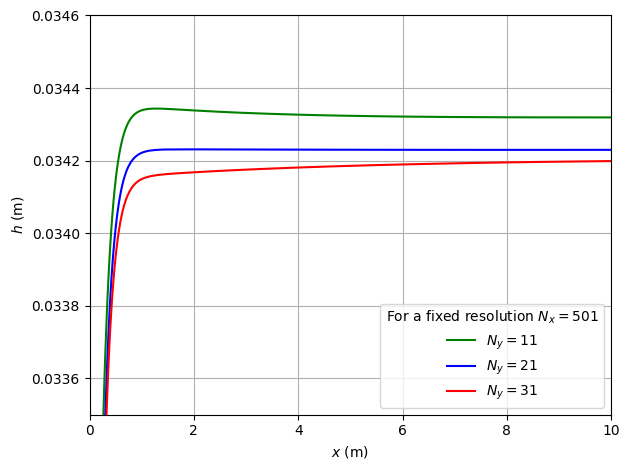

In [46]:
plt.figure()
plt.grid()
plt.xlabel('$x$ (m)')
plt.ylabel('$h$ (m)')
plt.xlim(0,10)
plt.ylim(0.0335, 0.0346)
plt.plot(np.linspace(0,10,mesh3_h.shape[0]), mesh3_h, color='green', label='$N_{y} = 11$')
plt.plot(np.linspace(0,10,mesh3_h.shape[0]), mesh2ny_h, color='blue', label='$N_{y} = 21$')
plt.plot(np.linspace(0,10,mesh3_h.shape[0]), mesh3ny_h, color='red', label='$N_{y} = 31$')
plt.legend(title='For a fixed resolution $N_{x}=501$')
plt.tight_layout()
#plt.savefig('/home/yts/dassflow2d/cases/steady_uniform_tests/grid_sensitivity_Ny.png', dpi=300)

In [48]:
np.savetxt('/home/yts/dassflow2d/cases/steady_uniform_tests/grid_sensitivity_results/results_mesh501_31.txt', mesh3ny_h)

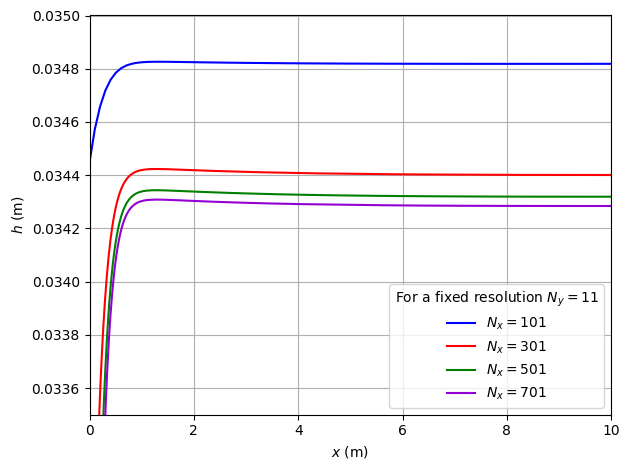

In [39]:
plt.figure()
plt.grid()
plt.xlabel('$x$ (m)')
plt.ylabel('$h$ (m)')
plt.xlim(0,10)
plt.ylim(0.0335, 0.035)
plt.plot(np.linspace(0,10,mesh1_h.shape[0]), mesh1_h, color='blue', label='$N_{x} = 101$')
plt.plot(np.linspace(0,10,mesh2_h.shape[0]), mesh2_h, color='red', label='$N_{x} = 301$')
plt.plot(np.linspace(0,10,mesh3_h.shape[0]), mesh3_h, color='green', label='$N_{x} = 501$')
plt.plot(np.linspace(0,10,mesh4_h.shape[0]), mesh4_h, color='darkviolet', label='$N_{x} = 701$')
plt.legend(title='For a fixed resolution $N_{y}=11$')
plt.tight_layout()
#plt.savefig('/home/yts/dassflow2d/cases/steady_uniform_tests/grid_sensitivity_Nx.png', dpi=300)

In [38]:
#np.savetxt('/home/yts/dassflow2d/cases/steady_uniform_tests/grid_sensitivity_results/results_mesh701.txt', mesh4_h)

In [86]:
rho, mu, g = 1406, 12, 9.81
L, theta, H = 0.24, np.deg2rad(3), 0.03
t_star = np.linspace(10**-2, 100, 1001)
t = (t_star*12*mu*L**2)/(rho*g*np.cos(theta)*H**3)
t_dim = np.linspace(0.1, 10, 1001)
t_adim = ((rho*g*np.cos(theta)*H**3)*t_dim)/(12*mu*L**2)
t_adim

array([0.00448371, 0.0049276 , 0.00537148, ..., 0.44748323, 0.44792712,
       0.44837101])